# 서울시 유동인구 대비 버스 정류장 분석

**가설 1**: 유동인구 대비 버스 정류장수가 적은 구는 대중교통 수요가 충족되지 못하고 있다

**


---

##   1. 라이브러리 불러오기

In [52]:
!apt-get -y install fonts-nanum
!fc-cache -fv
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 48 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [54]:
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 한글 폰트 등록
font_dirs = ['/usr/share/fonts/truetype/nanum']
font_files = fm.findSystemFonts(fontpaths=font_dirs)
for f in font_files:
    fm.fontManager.addfont(f)

# NanumGothic 고정 지정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.sans-serif'] = ['NanumGothic']
plt.rcParams['axes.unicode_minus'] = False

sns.set_style('whitegrid')

# 팔레트 설정
palette = {
    'primary': '#163418',
    'accent': '#D4EC73',
    'neutral': '#F8F9F6',
    'text': '#707070',
    'highlight': '#DDF08A',
    'alert': '#FF6B6B',
    'ok': '#4ECDC4',
}

plt.rcParams['axes.facecolor'] = palette['neutral']
plt.rcParams['figure.facecolor'] = palette['neutral']
plt.rcParams['axes.labelcolor'] = palette['primary']
plt.rcParams['xtick.color'] = palette['text']
plt.rcParams['ytick.color'] = palette['text']

✅ 나눔고딕 폰트 적용 완료!


##   2. 데이터 로딩

In [55]:
# 데이터 로드
df_people = pd.read_csv('/content/drive/MyDrive/AI+X/bus/df_seoul_people.csv')
df_business = pd.read_csv('/content/drive/MyDrive/AI+X/bus/df_seoul_business.csv')
df_bus = pd.read_csv('/content/drive/MyDrive/AI+X/bus/df_seoul_bus_station.csv')
df_moving = pd.read_csv('/content/drive/MyDrive/AI+X/bus/df_seoul_moving.csv')


print(f"\n  데이터 로드 완료!")
print(f"   - 인구 데이터: {len(df_people)}개 자치구")
print(f"   - 사업체 데이터: {len(df_business)}개 동")
print(f"   - 버스정류장 데이터: {len(df_bus)}개 자치구")
print(f"   - 유동인구 데이터: {len(df_moving):,}개 행")


  데이터 로드 완료!
   - 인구 데이터: 25개 자치구
   - 사업체 데이터: 451개 동
   - 버스정류장 데이터: 25개 자치구
   - 유동인구 데이터: 9,555,938개 행


##   3. 데이터 탐색

In [56]:
# 인구 데이터 확인
print("  인구 데이터 미리보기:")
display(df_people.head())
print(f"\n컬럼: {df_people.columns.tolist()}")

  인구 데이터 미리보기:


,자치구,세대수,총인구,한국인,외국인,세대당인구,고령자
0,종로구,73766,153684,144275,9409,1.96,28064
1,중구,63767,131450,122173,9277,1.92,24742
2,용산구,111207,236518,222169,14349,2.00,39461
3,성동구,134533,291609,285073,6536,2.12,46896
4,광진구,169483,353110,340707,12403,2.01,52604



컬럼: ['자치구', '세대수', '총인구', '한국인', '외국인', '세대당인구', '고령자']


In [57]:
# 버스정류장 데이터 확인
print("  버스정류장 데이터 미리보기:")
display(df_bus.head())
print(f"\n컬럼: {df_bus.columns.tolist()}")

  버스정류장 데이터 미리보기:


,자치구,정류장수,노선수,승차총승객수,하차총승객수,승차평균승객수,하차평균승객수
0,강남구,499,91,8030483,7569213,128.767927,121.371512
1,강동구,369,21,2890053,2830506,99.161194,97.118065
2,강북구,413,67,4825181,4671783,133.020373,128.791504
3,강서구,566,49,4681083,4652828,88.119480,87.587591
4,관악구,466,86,7655819,7792476,154.753674,157.516040



컬럼: ['자치구', '정류장수', '노선수', '승차총승객수', '하차총승객수', '승차평균승객수', '하차평균승객수']


In [58]:
# 유동인구 데이터 확인
print("  유동인구 데이터 미리보기:")
display(df_moving.tail(100))
print(f"\n컬럼: {df_moving.columns.tolist()}")
print(f"\n데이터 크기: {df_moving.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

  유동인구 데이터 미리보기:


,대상연월,요일,도착시간,출발 시군구 코드,도착 시군구 코드,성별,나이,이동유형,평균 이동 시간(분),이동인구(합)
9555838,202204,토,23,11250,11250,M,25,EH,20,1151
9555839,202204,토,23,11250,11250,M,25,WH,20,455
9555840,202204,토,23,11250,11250,M,25,WE,20,81
9555841,202204,토,23,11250,11250,M,25,EW,20,63
9555842,202204,토,23,11250,11250,M,25,WW,20,58
...,...,...,...,...,...,...,...,...,...,...
9555933,202204,토,23,11250,11250,M,80,WH,10,85
9555934,202204,토,23,11250,11250,M,80,EH,10,28
9555935,202204,토,23,11250,11250,M,80,EE,20,37
9555936,202204,토,23,11250,11250,M,80,HE,10,9



컬럼: ['대상연월', '요일', '도착시간', '출발 시군구 코드', '도착 시군구 코드', '성별', '나이', '이동유형', '평균 이동 시간(분)', '이동인구(합)']

데이터 크기: 2050.68 MB


##   4. 자치구 코드 매핑

In [59]:
# 자치구 코드와 이름 매핑
standard = pd.DataFrame({
    '도착 시군구 코드': [11010, 11020, 11030, 11040, 11050, 11060, 11070, 11080,
                  11090, 11100, 11110, 11120, 11130, 11140, 11150, 11160,
                  11170, 11180, 11190, 11200, 11210, 11220, 11230, 11240, 11250],
    '자치구': ['종로구','중구','용산구','성동구','광진구','동대문구','중랑구','성북구',
           '강북구','도봉구','노원구','은평구','서대문구','마포구','양천구','강서구',
           '구로구','금천구','영등포구','동작구','관악구','서초구','강남구','송파구','강동구']
})

display(standard)

,도착 시군구 코드,자치구
0,11010,종로구
1,11020,중구
2,11030,용산구
3,11040,성동구
4,11050,광진구
5,11060,동대문구
6,11070,중랑구
7,11080,성북구
8,11090,강북구
9,11100,도봉구


##   5. 유동인구 집계

In [60]:
# 도착 기준 유동인구
유동인구_도착 = df_moving.groupby('도착 시군구 코드')['이동인구(합)'].sum().reset_index()
유동인구_도착.columns = ['도착 시군구 코드', '총유동인구_도착']

# 출발 기준 유동인구
유동인구_출발 = df_moving.groupby('출발 시군구 코드')['이동인구(합)'].sum().reset_index()
유동인구_출발.columns = ['출발 시군구 코드', '총유동인구_출발']

# 자치구명 매핑
유동인구_도착 = pd.merge(유동인구_도착, standard,
                      left_on='도착 시군구 코드', right_on='도착 시군구 코드')
유동인구_출발 = pd.merge(유동인구_출발, standard,
                      left_on='출발 시군구 코드', right_on='도착 시군구 코드')

# 도착 + 출발 합산
유동인구 = pd.merge(
    유동인구_도착[['자치구', '총유동인구_도착']],
    유동인구_출발[['자치구', '총유동인구_출발']],
    on='자치구'
)
유동인구['총유동인구'] = 유동인구['총유동인구_도착'] + 유동인구['총유동인구_출발']

print(f"  유동인구 집계 완료!")
display(유동인구.nlargest(10, '총유동인구'))

  유동인구 집계 완료!


,자치구,총유동인구_도착,총유동인구_출발,총유동인구
22,강남구,44640940,44118057,88758997
23,송파구,34842546,34920652,69763198
21,서초구,28899463,28661634,57561097
18,영등포구,24993713,24902833,49896546
13,마포구,23631678,23346132,46977810
15,강서구,21880505,21770651,43651156
24,강동구,21164606,21339683,42504289
10,노원구,20654894,20790300,41445194
1,중구,19708166,19472719,39180885
0,종로구,19381653,19202412,38584065


##  6. 데이터 병합 및 지표 계산

In [61]:
# 버스정류장 데이터와 병합
분석_데이터 = pd.merge(유동인구, df_bus, on='자치구')

# 인구 데이터 병합
분석_데이터 = pd.merge(분석_데이터, df_people[['자치구', '총인구']], on='자치구')

# 주요 지표 계산
분석_데이터['유동인구당_정류장수'] = (
    분석_데이터['정류장수'] / 분석_데이터['총유동인구'] * 100000
).round(2)

분석_데이터['정류장당_유동인구'] = (
    분석_데이터['총유동인구'] / 분석_데이터['정류장수']
).round(0)

분석_데이터['정류장당_승객수'] = (
    분석_데이터['승차총승객수'] / 분석_데이터['정류장수']
).round(0)

분석_데이터['수요충족률'] = (
    분석_데이터['정류장당_승객수'] / 분석_데이터['정류장당_유동인구'] * 100
).round(2)

print(f" 병합 완료! 총 {len(분석_데이터)}개 자치구")
display(분석_데이터.head())

 병합 완료! 총 25개 자치구


,자치구,총유동인구_도착,총유동인구_출발,총유동인구,정류장수,노선수,승차총승객수,하차총승객수,승차평균승객수,하차평균승객수,총인구,유동인구당_정류장수,정류장당_유동인구,정류장당_승객수,수요충족률
0,종로구,19381653,19202412,38584065,349,106,5468935,5205394,131.889620,125.534028,153684,0.90,110556.0,15670.0,14.17
1,중구,19708166,19472719,39180885,178,103,3776675,3598932,121.020124,115.324511,131450,0.45,220117.0,21217.0,9.64
2,용산구,14725893,14539086,29264979,323,67,4189977,4086474,137.891694,134.485421,236518,1.10,90604.0,12972.0,14.32
3,성동구,17462110,17535356,34997466,435,58,2807280,2746738,96.377369,94.298888,291609,1.24,80454.0,6454.0,8.02
4,광진구,17972853,17931607,35904460,269,41,2749448,2753411,118.352546,118.523137,353110,0.75,133474.0,10221.0,7.66


## 7. 상관관계 분석

In [62]:
# 상관관계 매트릭스
분석_컬럼 = ['총유동인구', '정류장수', '노선수', '승차총승객수', '총인구']
corr_matrix = 분석_데이터[분석_컬럼].corr()

print("  상관관계 매트릭스:")
display(corr_matrix.round(3))

# 핵심 상관관계
print("\n  핵심 상관관계:")
print(f"   유동인구 vs 정류장수: {corr_matrix.loc['총유동인구', '정류장수']:.3f}")
print(f"   유동인구 vs 승차승객수: {corr_matrix.loc['총유동인구', '승차총승객수']:.3f}")
print(f"   정류장수 vs 승차승객수: {corr_matrix.loc['정류장수', '승차총승객수']:.3f}")

  상관관계 매트릭스:


,총유동인구,정류장수,노선수,승차총승객수,총인구
총유동인구,1.000,0.358,0.222,0.577,0.536
정류장수,0.358,1.000,0.259,0.567,0.567
노선수,0.222,0.259,1.000,0.665,-0.282
승차총승객수,0.577,0.567,0.665,1.000,0.364
총인구,0.536,0.567,-0.282,0.364,1.000



  핵심 상관관계:
   유동인구 vs 정류장수: 0.358
   유동인구 vs 승차승객수: 0.577
   정류장수 vs 승차승객수: 0.567


In [63]:
# 통계적 유의성 검정
r_pearson, p_pearson = pearsonr(분석_데이터['총유동인구'], 분석_데이터['승차총승객수'])
r_spearman, p_spearman = spearmanr(분석_데이터['총유동인구'], 분석_데이터['승차총승객수'])

print(f"   유동인구 vs 버스 이용량 통계:")
print(f"   Pearson 상관계수: {r_pearson:.3f} (p-value: {p_pearson:.4f})")
print(f"   Spearman 상관계수: {r_spearman:.3f} (p-value: {p_spearman:.4f})")

if p_pearson < 0.05:
    print(f" 통계적으로 유의함! (p < 0.05)")
else:
    print(f" 통계적으로 유의하지 않음 (p >= 0.05)")

   유동인구 vs 버스 이용량 통계:
   Pearson 상관계수: 0.577 (p-value: 0.0025)
   Spearman 상관계수: 0.443 (p-value: 0.0265)
 통계적으로 유의함! (p < 0.05)


## 8. 정류장 부족/충분 지역 분석

In [64]:
# 정류장 부족 지역 TOP 5
print("정류장 부족 지역 TOP 5")

부족지역 = 분석_데이터.nlargest(5, '정류장당_유동인구')[[
    '자치구', '총유동인구', '정류장수', '정류장당_유동인구',
    '승차총승객수', '정류장당_승객수', '수요충족률'
]]

display(부족지역)

정류장 부족 지역 TOP 5


,자치구,총유동인구,정류장수,정류장당_유동인구,승차총승객수,정류장당_승객수,수요충족률
1,중구,39180885,178,220117.0,3776675,21217.0,9.64
22,강남구,88758997,499,177874.0,8030483,16093.0,9.05
23,송파구,69763198,415,168104.0,5641742,13595.0,8.09
4,광진구,35904460,269,133474.0,2749448,10221.0,7.66
24,강동구,42504289,369,115188.0,2890053,7832.0,6.80


In [65]:
# 정류장 충분 지역 TOP 5
print("  정류장 충분 지역 TOP 5")
print("="*80)

충분지역 = 분석_데이터.nsmallest(5, '정류장당_유동인구')[[
    '자치구', '총유동인구', '정류장수', '정류장당_유동인구',
    '승차총승객수', '정류장당_승객수', '수요충족률'
]]

display(충분지역)

  정류장 충분 지역 TOP 5


,자치구,총유동인구,정류장수,정류장당_유동인구,승차총승객수,정류장당_승객수,수요충족률
17,금천구,16403453,345,47546.0,3776658,10947.0,23.02
16,구로구,29088069,486,59852.0,4942197,10169.0,16.99
9,도봉구,21903071,359,61011.0,3304305,9204.0,15.09
8,강북구,25313634,413,61292.0,4825181,11683.0,19.06
7,성북구,37742490,602,62695.0,6236424,10360.0,16.52


##  9. 시각화

In [67]:
# matplotlib 폰트 설정 업데이트
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

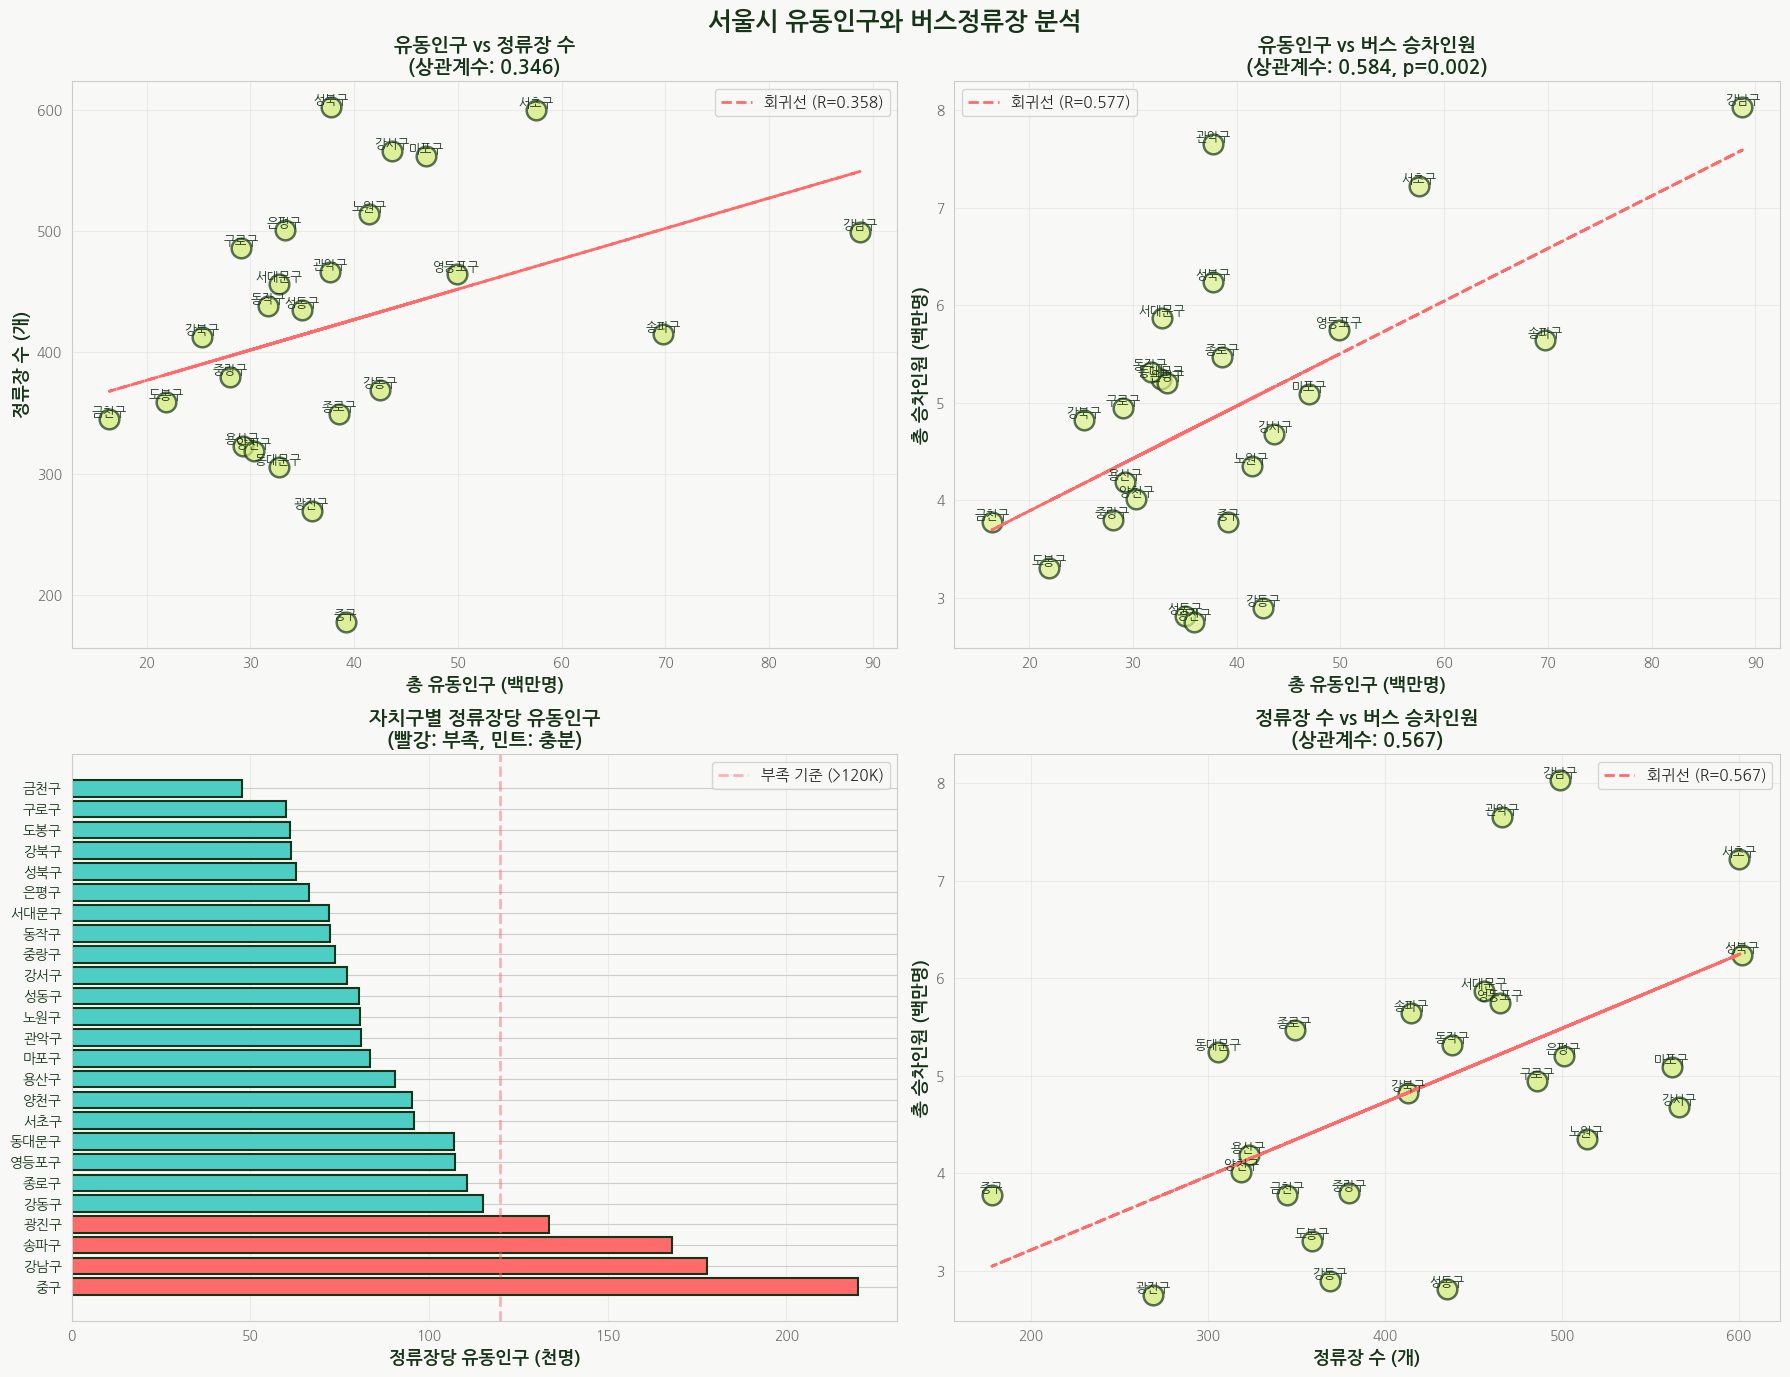

In [69]:
# Figure 생성
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('서울시 유동인구와 버스정류장 분석', fontsize=18, fontweight='bold', color=palette['primary'])

# 1. 유동인구 vs 정류장수
ax1 = axes[0, 0]
x1 = 분석_데이터['총유동인구'] / 1000000
y1 = 분석_데이터['정류장수']
ax1.scatter(x1, y1, s=200, alpha=0.7,
            c=palette['accent'], edgecolors=palette['primary'], linewidth=1.8)

slope1, intercept1, r1, p1, se1 = linregress(x1, y1)
line1 = slope1 * x1 + intercept1
ax1.plot(x1, line1, color=palette['alert'], linestyle='--', linewidth=2,
         label=f'회귀선 (R={r1:.3f})')

for idx, row in 분석_데이터.iterrows():
    ax1.annotate(row['자치구'], (row['총유동인구']/1000000, row['정류장수']),
                fontsize=9, ha='center', va='bottom', color=palette['primary'])

ax1.set_xlabel('총 유동인구 (백만명)', fontsize=13, fontweight='bold')
ax1.set_ylabel('정류장 수 (개)', fontsize=13, fontweight='bold')
ax1.set_title('유동인구 vs 정류장 수\n(상관계수: 0.346)', fontsize=14, fontweight='bold', color=palette['primary'])
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 2. 유동인구 vs 승차승객수
ax2 = axes[0, 1]
x2 = 분석_데이터['총유동인구'] / 1000000
y2 = 분석_데이터['승차총승객수'] / 1000000
ax2.scatter(x2, y2, s=200, alpha=0.7,
            c=palette['highlight'], edgecolors=palette['primary'], linewidth=1.8)

slope2, intercept2, r2, p2, se2 = linregress(x2, y2)
line2 = slope2 * x2 + intercept2
ax2.plot(x2, line2, color=palette['alert'], linestyle='--', linewidth=2,
         label=f'회귀선 (R={r2:.3f})')

for idx, row in 분석_데이터.iterrows():
    ax2.annotate(row['자치구'], (row['총유동인구']/1000000, row['승차총승객수']/1000000),
                fontsize=9, ha='center', va='bottom', color=palette['primary'])

ax2.set_xlabel('총 유동인구 (백만명)', fontsize=13, fontweight='bold')
ax2.set_ylabel('총 승차인원 (백만명)', fontsize=13, fontweight='bold')
ax2.set_title('유동인구 vs 버스 승차인원\n(상관계수: 0.584, p=0.002)', fontsize=14, fontweight='bold', color=palette['primary'])
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# 3. 정류장당 유동인구
ax3 = axes[1, 0]
sorted_data = 분석_데이터.sort_values('정류장당_유동인구', ascending=False)
colors = [palette['alert'] if x > 120000 else palette['ok']
          for x in sorted_data['정류장당_유동인구']]

ax3.barh(range(len(sorted_data)), sorted_data['정류장당_유동인구']/1000,
        color=colors, edgecolor=palette['primary'], linewidth=1.5)
ax3.set_yticks(range(len(sorted_data)))
ax3.set_yticklabels(sorted_data['자치구'], fontsize=10, color=palette['primary'])
ax3.set_xlabel('정류장당 유동인구 (천명)', fontsize=13, fontweight='bold')
ax3.set_title('자치구별 정류장당 유동인구\n(빨강: 부족, 민트: 충분)', fontsize=14, fontweight='bold', color=palette['primary'])
ax3.axvline(120, color=palette['alert'], linestyle='--', alpha=0.5, linewidth=2, label='부족 기준 (>120K)')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3, axis='x')

# 4. 정류장수 vs 승차승객수
ax4 = axes[1, 1]
x4 = 분석_데이터['정류장수']
y4 = 분석_데이터['승차총승객수'] / 1000000
ax4.scatter(x4, y4, s=200, alpha=0.7,
            c=palette['accent'], edgecolors=palette['primary'], linewidth=1.8)

slope4, intercept4, r4, p4, se4 = linregress(x4, y4)
line4 = slope4 * x4 + intercept4
ax4.plot(x4, line4, color=palette['alert'], linestyle='--', linewidth=2,
         label=f'회귀선 (R={r4:.3f})')

for idx, row in 분석_데이터.iterrows():
    ax4.annotate(row['자치구'], (row['정류장수'], row['승차총승객수']/1000000),
                fontsize=9, ha='center', va='bottom', color=palette['primary'])

ax4.set_xlabel('정류장 수 (개)', fontsize=13, fontweight='bold')
ax4.set_ylabel('총 승차인원 (백만명)', fontsize=13, fontweight='bold')
ax4.set_title('정류장 수 vs 버스 승차인원\n(상관계수: 0.567)', fontsize=14, fontweight='bold', color=palette['primary'])
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. 최종 결론

## 가설: "유동인구 대비 버스 정류장수가 적은 구는 대중교통 수요가 충족되지 못하고 있다"


## 결론: 부분적(특정 지역적)으로 입증됨!

확인하기 위해 서울시 각 구별로 1 - 총 유동인구, 2 - 버스정류장 수, 3 - 버스 승차 인원을 수집·결합하여 상관분석과 시각화를 진행


## 통계적 근거:
- 유동인구 vs 승차승객수 상관계수: **0.584** (p=0.002, 통계적으로 유의)
- 유동인구 vs 정류장수 상관계수: **0.346** (약한 상관)
- 정류장 수 vs 버스 승차인원: **0.567**


## 1. 유동인구와 정류장 수의 관계

'유동인구 vs 정류장 수' 그래프에서 회귀선의 기울기는 양수이며 상관계수는 0.346으로 나옴

서울시 전체적으로 볼 때 유동인구가 증가하면 정류장 수도 증가하는 경향이 있음을 보여주지만 그 강도는 크지 않음을 알 수 있음

이 회귀선 아래에 위치한 **중구, 성동구, 광진구** 등은 **동일한 유동인구 규모를 가진 다른 구에 비해 정류장 수가 상대적으로 적은 구**로 해석할 수 있음

이는 곧 대중교통 이용에서 취약한 구역일 가능성을 의미함

반대로 성북구, 강북구처럼 회귀선 위에 크게 위치한 구는 유동인구에 비해 정류장이 상대적으로 많이 공급된 구로 해석할 수 있음


## 2. 유동인구와 실제 이용(버스 승차인원)의 관계

'유동인구 vs 버스 승차인원' 그래프에서는 상관계수가 0.584, p=0.002로 나타나 유동인구가 많아질수록 실제 버스 이용도 증가함을 보여줌

이 결과를 통해서 첫 번째 그래프와 결합해 해석하면. 유동인구와 버스 이용 상관 관계를 가지는데(0.584)반해, 유동인구와 정류장 수는 그만큼의 상관 관계를 가지지 않는 것을 알 수 있음(0.346).

즉, 유동인구와 정류장 수 간의 상관 구조가 약한 상태이며,
특정한 구에서 공급이 정류장 수가 유동인구를 확실하게 반영하지 못하는 현상이 존재함을 알 수 있음


## 3. 정류장 수와 버스 승차인원의 관계

'정류장 수 vs 버스 승차인원' 그래프의 상관계수는 0.567로, 정류장 공급이 늘수록 이용량도 함께 증가하는 양의 상관 관계임을 알 수 있음

그러나 여기에서도 회귀선 위의 구는 정류장 1개당 이용 효율이 높은 곳으로, 이 지역은 정류장 추가가 실제 혼잡 완화에 대한 해답으로 이어질 수 잇는 구 임을 알 수 있었음


## 4. 정류장당 유동인구

하단 왼쪽 막대그래프에서는 구별로 '정류장 1곳이 담당하는 유동인구'를 비교하고, 임의의 기준선(예: 30K명은 적정, 50K명을 넘기면 부족)으로 구간을 나누어 표시

이 그림에서 붉은색으로 표시된 중구, 성동구, 광진구, 동작구 등은 정류장 하나가 담당해야 하는 인구가 다른 구보다 훨씬 많아은 구로 나타났음

산점도에서 회귀선 아래에 있던 구들과 유사한 결과이며, "유동인구 대비 정류장 수가 적은 구"를 골라낼 수 있음

##  정류장 부족 지역:
- **중구, 강남구, 송파구**는 정류장당 유동인구가 압도적으로 높음
- 실제 버스 이용 수요도 높아 정류장 확충 필요

## 정류장 충분 지역:
- 앞의 부족 지역과는 반대로 **금천구, 구로구** 등은 정류장 수는 충분

## 결론
서울시 전체는 유동인구가 많아질수록 버스 이용도 증가

그것과는 다르게 유동인구 증가와 정류장 수는 그만 큼 상관 관계를 가지지 못함

그 결과 일부 구(중구, 성동구, 광진구 등)는 실제 이동 수요에 비해 버스 정류장 공급이 상대적으로 부족한 상태임을 알 수 있음!

그래서 서울시 전체에 해당 가설이 맞다고 볼 수는 없지만 특정 지역으로 범위로 좁혀서 확인한다면 가설이 성립함을 알 수 있음!


## 해결 방안 생각 및 가설 2번으로 확장:

- 중구/강남구/송파구: 주요 유동 구간에 정류장 증설 + **피크 시간대(출.퇴근 배차 간격 단축)**

## 가설2 : 출퇴근 시간대(07 ~ 09시, 18 ~ 20시) 에는 정류장이 많더라도 몰리는 인구를 충분히 흡수하지 못한다.즉, 시간대별 수요 집중이 커서 정류장 수와 유동인구의 관계가 약화된다.

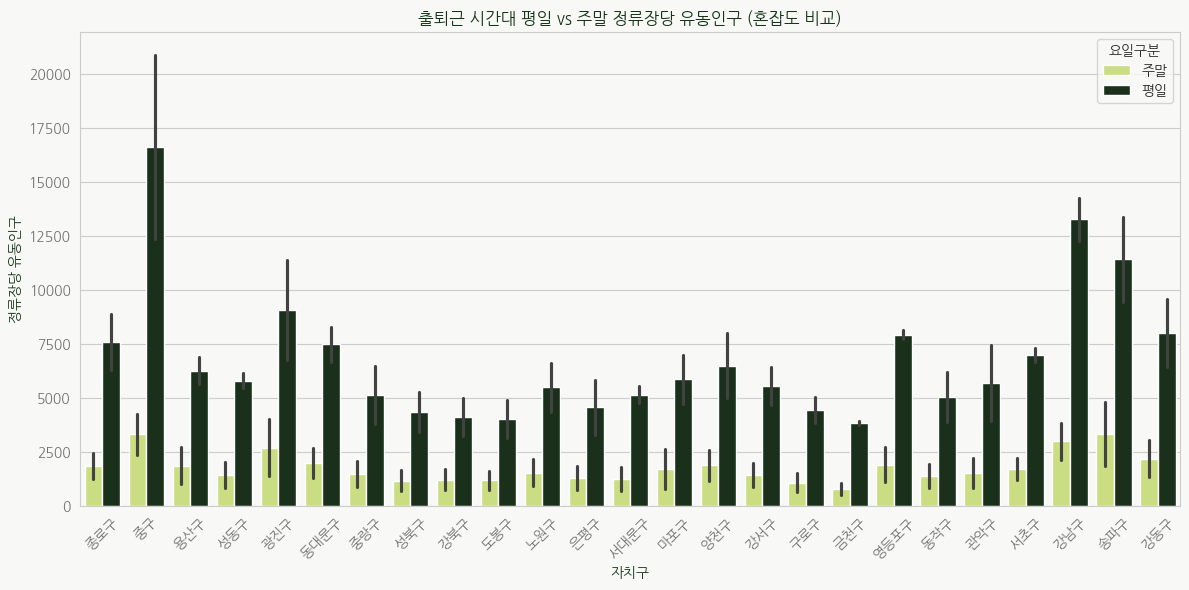


[평일 기준 시간대별 정류장 수 vs 유동인구 상관계수]


,시간대구분,상관계수
0,출근,0.218988
1,퇴근,0.468762
2,기타,0.353224


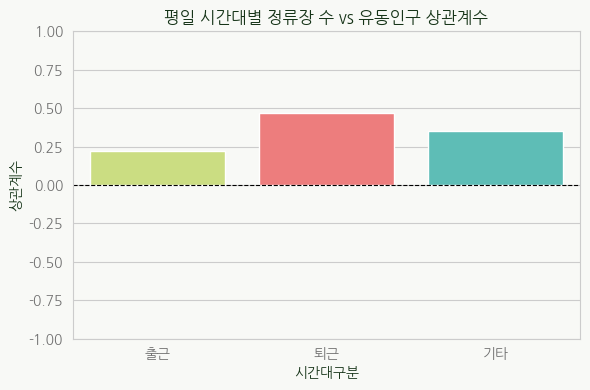

 출근 시간대(평일) 혼잡도 상위 5개 구


,자치구,혼잡도(인/정류장)
10,중구,20874.044944
136,강남구,14267.050100
142,송파구,9450.178313
4,종로구,8878.985673
112,영등포구,8154.096774


 퇴근 시간대(평일) 혼잡도 상위 5개 구


,자치구,혼잡도(인/정류장)
143,송파구,13377.518072
11,중구,12349.213483
137,강남구,12279.058116
29,광진구,11393.122677
149,강동구,9569.674797


 출퇴근 시간대 평일-주말 혼잡도 격차 상위 구


요일구분,자치구,시간대구분,주말,평일,평일-주말 격차
46,중구,출근,2352.028090,20874.044944,18522.016854
0,강남구,출근,2141.623246,14267.050100,12125.426854
35,송파구,퇴근,4785.281928,13377.518072,8592.236145
1,강남구,퇴근,3841.865731,12279.058116,8437.192385
47,중구,퇴근,4247.483146,12349.213483,8101.730337
44,종로구,출근,1225.108883,8878.985673,7653.876791
34,송파구,출근,1818.187952,9450.178313,7631.990361
11,광진구,퇴근,4012.873606,11393.122677,7380.249071
38,영등포구,출근,1103.230108,8154.096774,7050.866667
3,강동구,퇴근,3023.127371,9569.674797,6546.547425


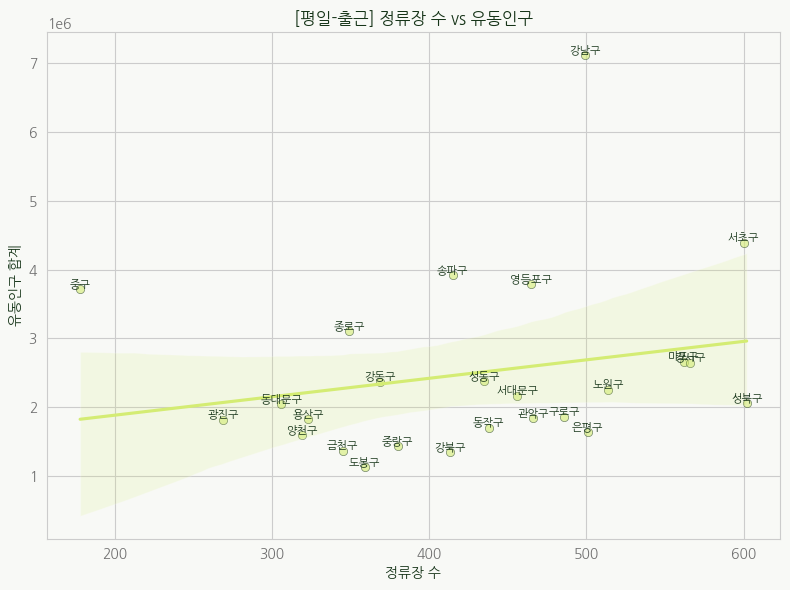

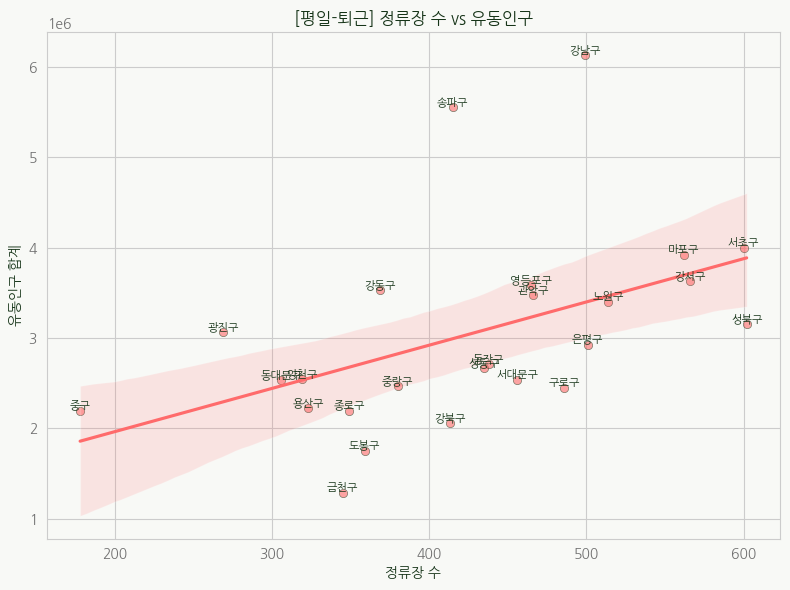

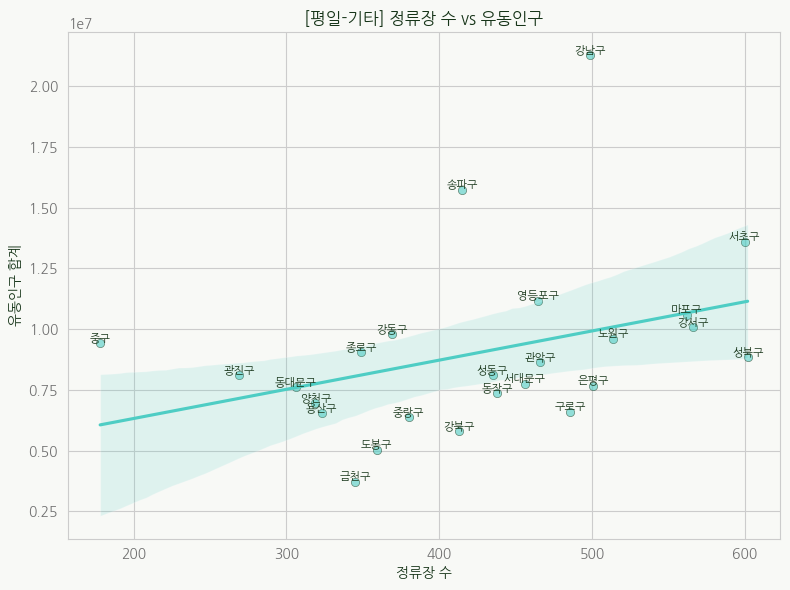

In [70]:
# =============================================================
#  가설 2. 특정 시간대(출퇴근)에는 정류장 수가 유동인구 증가를 충분히 흡수하지 못한다.
# =============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
#  요일/시간대 분류
# -------------------------------------------------------------
def classify_day(d):
    return '주말' if d in ['토', '일'] else '평일'

def classify_time(h):
    if 7 <= h <= 9:
        return '출근'
    elif 18 <= h <= 20:
        return '퇴근'
    else:
        return '기타'

df_moving['요일구분'] = df_moving['요일'].apply(classify_day)
df_moving['시간대구분'] = df_moving['도착시간'].apply(classify_time)

# -------------------------------------------------------------
#  자치구별·요일별·시간대별 유동인구 집계
#    (도착 기준으로 집계 → 자치구 코드와 매핑)
# -------------------------------------------------------------
flow = (
    df_moving.groupby(['도착 시군구 코드', '요일구분', '시간대구분'])['이동인구(합)']
    .sum()
    .reset_index()
)

# 자치구 코드 → 이름 매핑
flow = pd.merge(flow, standard, on='도착 시군구 코드', how='left')

# 버스 정류장 데이터 병합
merged = pd.merge(flow, df_bus, on='자치구', how='left')

# 정류장당 유동인구(혼잡도)
merged['혼잡도(인/정류장)'] = merged['이동인구(합)'] / merged['정류장수']

# -------------------------------------------------------------
# 시각화 – 출근/퇴근 시간대 평일 vs 주말 비교
# -------------------------------------------------------------
plt.figure(figsize=(12,6))
sns.barplot(
    data=merged[merged['시간대구분'].isin(['출근', '퇴근'])],
    x='자치구', y='혼잡도(인/정류장)',
    hue='요일구분',
    # 템플릿 색상 적용
    palette={'평일': palette['primary'], '주말': palette['accent']}
)
plt.title('출퇴근 시간대 평일 vs 주말 정류장당 유동인구 (혼잡도 비교)', color=palette['primary'])
plt.xticks(rotation=45)
plt.ylabel('정류장당 유동인구')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
#  시간대별 상관관계 (정류장수 vs 유동인구) – 평일 기준
# -------------------------------------------------------------
corr_list = []
for t in ['출근', '퇴근', '기타']:
    data_t = merged[(merged['시간대구분'] == t) & (merged['요일구분'] == '평일')]
    if len(data_t) > 1:
        corr_val = data_t[['정류장수', '이동인구(합)']].corr().loc['정류장수', '이동인구(합)']
    else:
        corr_val = float('nan')
    corr_list.append({'시간대구분': t, '상관계수': corr_val})

corr_result = pd.DataFrame(corr_list)
print("\n[평일 기준 시간대별 정류장 수 vs 유동인구 상관계수]")
display(corr_result)

plt.figure(figsize=(6,4))
sns.barplot(
    data=corr_result,
    x='시간대구분', y='상관계수',
    # 출근-퇴근-기타 순서로 템플릿 색 적용
    palette=[palette['accent'], palette['alert'], palette['ok']]
)
plt.title('평일 시간대별 정류장 수 vs 유동인구 상관계수', color=palette['primary'])
plt.ylim(-1, 1)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
#  출근/퇴근 시간대 혼잡 상위 구 확인 (평일만)
# -------------------------------------------------------------
top5_morning = (
    merged[(merged['시간대구분'] == '출근') & (merged['요일구분'] == '평일')]
    .sort_values('혼잡도(인/정류장)', ascending=False)
    .head(5)
)
print(" 출근 시간대(평일) 혼잡도 상위 5개 구")
display(top5_morning[['자치구', '혼잡도(인/정류장)']])

top5_evening = (
    merged[(merged['시간대구분'] == '퇴근') & (merged['요일구분'] == '평일')]
    .sort_values('혼잡도(인/정류장)', ascending=False)
    .head(5)
)
print(" 퇴근 시간대(평일) 혼잡도 상위 5개 구")
display(top5_evening[['자치구', '혼잡도(인/정류장)']])

# -------------------------------------------------------------
#  평일-주말 격차로 '특히 평일에만' 터지는 구 찾기
# -------------------------------------------------------------
pivot_cong = (
    merged[merged['시간대구분'].isin(['출근', '퇴근'])]
    .pivot_table(
        index=['자치구', '시간대구분'],
        columns='요일구분',
        values='혼잡도(인/정류장)',
        aggfunc='mean'
    )
    .reset_index()
)
# 격차 컬럼 추가
if '평일' in pivot_cong.columns and '주말' in pivot_cong.columns:
    pivot_cong['평일-주말 격차'] = pivot_cong['평일'] - pivot_cong['주말']
    print(" 출퇴근 시간대 평일-주말 혼잡도 격차 상위 구")
    display(
        pivot_cong.sort_values('평일-주말 격차', ascending=False).head(10)
    )

# -------------------------------------------------------------
# 시간대별 개별 산점도 (평일만, 자치구 이름 표시)
# -------------------------------------------------------------
time_labels = ['출근', '퇴근', '기타']
# 템플릿 기반 색상으로 교체
color_map = {
    '출근': palette['accent'],
    '퇴근': palette['alert'],
    '기타': palette['ok'],
}

for t in time_labels:
    data_t = merged[(merged['시간대구분'] == t) & (merged['요일구분'] == '평일')]

    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=data_t,
        x='정류장수', y='이동인구(합)',
        color=color_map[t], alpha=0.6, edgecolor=palette['primary']
    )
    # 회귀선
    if len(data_t) > 1:
        sns.regplot(
            data=data_t,
            x='정류장수', y='이동인구(합)',
            scatter=False, color=color_map[t]
        )

    # 자치구 이름 표시
    for _, row in data_t.iterrows():
        plt.annotate(
            row['자치구'],
            (row['정류장수'], row['이동인구(합)']),
            fontsize=8,
            ha='center',
            va='bottom',
            color=palette['primary']
        )

    plt.title(f'[평일-{t}] 정류장 수 vs 유동인구', color=palette['primary'])
    plt.xlabel('정류장 수')
    plt.ylabel('유동인구 합계')
    plt.tight_layout()
    plt.show()

## 가설: “출퇴근 시간대(07 ~ 09시, 18 ~ 20시)에는 정류장이 많더라도 몰리는 인구를 충분히 흡수하지 못한다.즉, 특정 시간대의 수요 집중이 커서 정류장 수와 유동인구의 관계가 약화된다.”

특정 시간과의 상관 관계를 살펴보기!

## 결론
특정 시간대의 이동 집중으로 인해 정류장 수와 유동인구의 상관관계가 약화되는 것을 통해서 특정 지역의 특정 시간대에는 기존의 교통으로 이동을 충분히 분산 시키지 못하는 현상이 있다고 할 수 있다

## 통계적 근거
출근(07~09시) : 0.23 :매우 약한 양의 상관관계 -> 정류장 수가 많아도 유동인구 폭증 구간 존재 ( 거주지 -> 직장  움직임 )

퇴근(18~20시) : 0.47 : 중간 수준의 상관관계 -> 일부 지역에서 정류장 수가 수요에 반응하지만 한계 존재  ( 직작 -> 거주지  움직임 )

기타시간대 : 0.34 : 비교적 안정적 -> 출퇴근 외 시간대에는 정류장 수가 이동량과 비례

## 평일과 주말 혼잡도 비교
특정 시간대의 상관관계 비교 이전에 일이 많은 평일과 주말의 혼잡도를 비교
중구, 강남구, 송파구는
평일 기준 정류장 1곳당 유동인구가 9,000~20,000명 수준으로,
다른 지역 대비 약 2배 이상 높은 과밀 상태를 보여줌!

## 평일 주말 혼잡도 격차
자치구	시간대	평일-주말 격차
중구	출근	18,522
강남구	출근	12,125
송파구	퇴근	8,592
광진구	퇴근	7,380
영등포구	출근	7,050

중구, 강남구, 송파구, 광진구, 영등포구 등에서 평일 혼잡도가 주말 대비 현저히 높았다.
이는 평일 출퇴근 집중 현상이 도심과 주거지 간에 동시에 발생함

출근 시간대에는 업무 중심지(중구, 강남구)가,
퇴근 시간대에는 주거 밀집지(송파구, 광진구)가 혼잡의 중심으로 나타났음

## 종합

출근시간대 (07~09시)
+ 상관계수 0.23
+ 유동인구 집중률 최고 (중구·강남구 중심)
+ 정류장 수가 많아도 수요 폭증을 완화하지 못함

→ 정류장 증설보다 배차 간격 단축 및 집중 운행 필요

퇴근시간대 (18~20시)
+ 상관계수 0.47
+ 출근보다 완화되나 여전히 혼잡 지속 (송파·광진 중심)

→ 귀가 방향 중심의 배차 간격 단축 및 집중 운행 필요

출근시간대: 각 구 혼잡도 vs 중구 유입 인구 상관계수 = 0.635
출근 시간대(07~09시) 중구로 유입되는 인구 TOP 5 자치구:


,자치구,중구유입인구
23,중구,456982
16,성북구,227078
15,성동구,210814
21,은평구,198836
13,서대문구,187611


출근 시간대(07~09시) [중구 제외] 중구로 유입되는 인구 TOP 5 자치구:


,자치구,중구유입인구
16,성북구,227078
15,성동구,210814
21,은평구,198836
13,서대문구,187611
12,마포구,186630


퇴근 시간대(18~20시) 중구에서 빠져나가는 인구 TOP 5 자치구:


,자치구,중구발퇴근인구
23,중구,925610
22,종로구,285227
15,성동구,212721
20,용산구,205534
12,마포구,197072


퇴근 시간대(18~20시) [중구 제외] 중구에서 빠져나가는 인구 TOP 5 자치구:


,자치구,중구발퇴근인구
22,종로구,285227
15,성동구,212721
20,용산구,205534
12,마포구,197072
16,성북구,194420


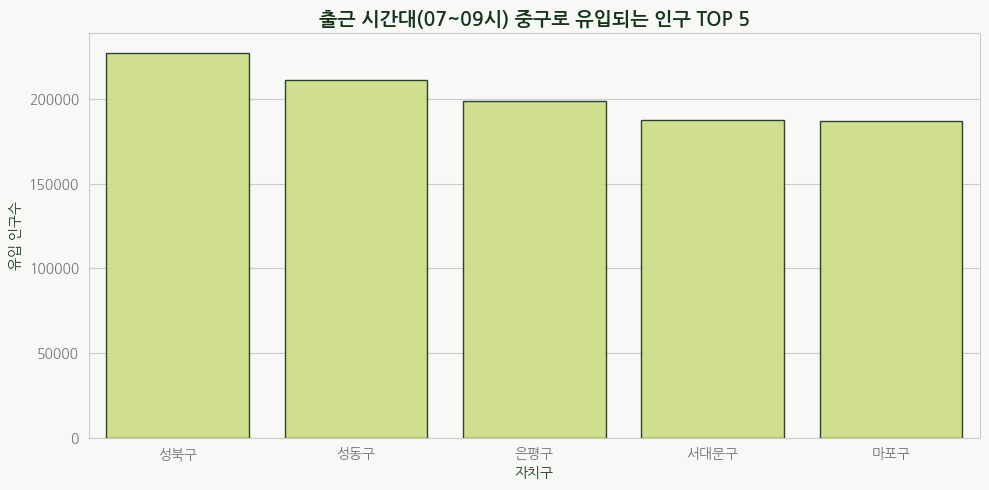

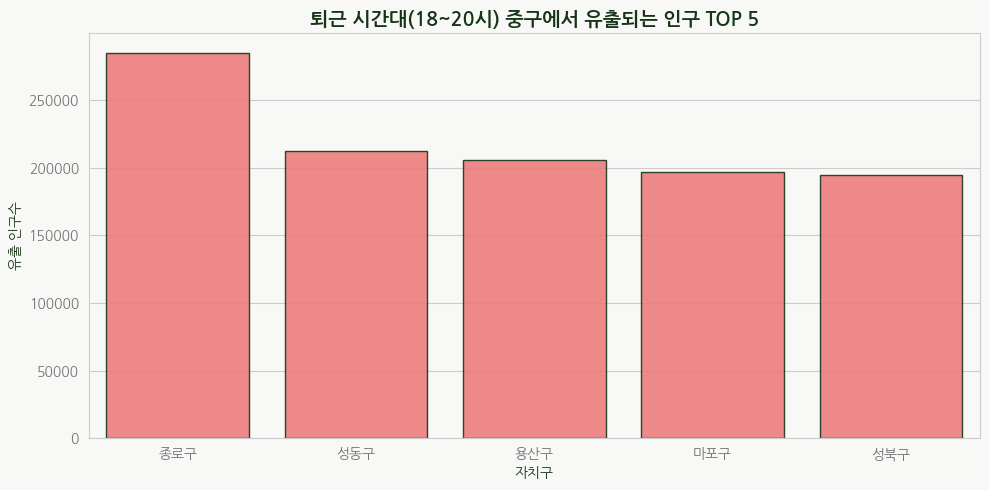

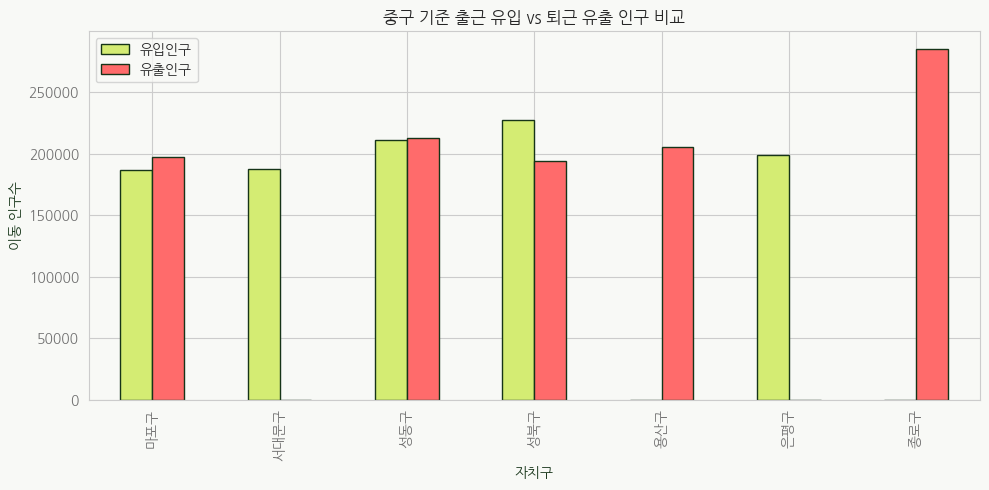

In [71]:
# =============================================================
#  가설 3. 중구 혼잡은 몇 개 구와의 이동이 집중돼서 생긴다
# =============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import warnings

# -------------------------------------------------------------
# 0. 테이블 만들기
# -------------------------------------------------------------
df_flow = (
    df_moving
    .groupby(['출발 시군구 코드', '도착 시군구 코드', '요일구분', '시간대구분'])['이동인구(합)']
    .sum()
    .reset_index()
)

# 출발 구 이름 붙이기
df_flow = pd.merge(
    df_flow,
    standard.rename(columns={'도착 시군구 코드': '출발 시군구 코드', '자치구': '출발자치구'}),
    on='출발 시군구 코드', how='left'
)

# 도착 구 이름 붙이기
df_flow = pd.merge(
    df_flow,
    standard.rename(columns={'도착 시군구 코드': '도착 시군구 코드', '자치구': '도착자치구'}),
    on='도착 시군구 코드', how='left'
)

# -------------------------------------------------------------
# 1. 각 구별 혼잡도 (평일·출근 기준)
# -------------------------------------------------------------
cong_df = (
    merged[(merged['시간대구분'] == '출근') & (merged['요일구분'] == '평일')]
    [['자치구', '혼잡도(인/정류장)']]
    .groupby('자치구', as_index=False)
    .mean()
)

# -------------------------------------------------------------
# 2. [출근] 중구로 유입되는 인구 (다른 구 → 중구)
# -------------------------------------------------------------
incoming_df = (
    df_flow[
        (df_flow['도착 시군구 코드'] == 11020) &
        (df_flow['시간대구분'] == '출근') &
        (df_flow['요일구분'] == '평일')
    ]
    .groupby('출발자치구', as_index=False)['이동인구(합)']
    .sum()
    .rename(columns={'출발자치구': '자치구', '이동인구(합)': '중구유입인구'})
)

# -------------------------------------------------------------
# 3. [출근] 혼잡도 vs 유입량 상관
# -------------------------------------------------------------
corr_df = pd.merge(cong_df, incoming_df, on='자치구', how='inner')
corr_val = corr_df['혼잡도(인/정류장)'].corr(corr_df['중구유입인구'])
print(f"출근시간대: 각 구 혼잡도 vs 중구 유입 인구 상관계수 = {corr_val:.3f}")

# -------------------------------------------------------------
# 4. [출근] 중구로 들어오는 TOP 5
# -------------------------------------------------------------
top5_incoming = incoming_df.sort_values('중구유입인구', ascending=False).head(5)
print("출근 시간대(07~09시) 중구로 유입되는 인구 TOP 5 자치구:")
display(top5_incoming)

top5_incoming_no_self = (
    incoming_df[incoming_df['자치구'] != '중구']
    .sort_values('중구유입인구', ascending=False)
    .head(5)
)
print("출근 시간대(07~09시) [중구 제외] 중구로 유입되는 인구 TOP 5 자치구:")
display(top5_incoming_no_self)

# -------------------------------------------------------------
# (중구 → 다른 구) 퇴근
# -------------------------------------------------------------
outgoing_df = (
    df_flow[
        (df_flow['출발 시군구 코드'] == 11020) &
        (df_flow['시간대구분'] == '퇴근') &
        (df_flow['요일구분'] == '평일')
    ]
    .groupby('도착자치구', as_index=False)['이동인구(합)']
    .sum()
    .rename(columns={'도착자치구': '자치구', '이동인구(합)': '중구발퇴근인구'})
)

top5_outgoing = outgoing_df.sort_values('중구발퇴근인구', ascending=False).head(5)
print("퇴근 시간대(18~20시) 중구에서 빠져나가는 인구 TOP 5 자치구:")
display(top5_outgoing)

top5_outgoing_no_self = (
    outgoing_df[outgoing_df['자치구'] != '중구']
    .sort_values('중구발퇴근인구', ascending=False)
    .head(5)
)
print("퇴근 시간대(18~20시) [중구 제외] 중구에서 빠져나가는 인구 TOP 5 자치구:")
display(top5_outgoing_no_self)

# -------------------------------------------------------------
# 5. 시각화 – palette 적용
# -------------------------------------------------------------
plt.figure(figsize=(10,5))
sns.barplot(data=top5_incoming_no_self, x='자치구', y='중구유입인구',
            color=palette['accent'], edgecolor=palette['primary'], alpha=0.9)
plt.title('출근 시간대(07~09시) 중구로 유입되는 인구 TOP 5',
          color=palette['primary'], fontsize=14, fontweight='bold')
plt.ylabel('유입 인구수', color=palette['primary'])
plt.xlabel('자치구', color=palette['primary'])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=top5_outgoing_no_self, x='자치구', y='중구발퇴근인구',
            color=palette['alert'], edgecolor=palette['primary'], alpha=0.9)
plt.title('퇴근 시간대(18~20시) 중구에서 유출되는 인구 TOP 5',
          color=palette['primary'], fontsize=14, fontweight='bold')
plt.ylabel('유출 인구수', color=palette['primary'])
plt.xlabel('자치구', color=palette['primary'])
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 6. 중구 기준 유입 vs 유출 비교
# -------------------------------------------------------------
compare_df = pd.merge(
    top5_incoming_no_self.rename(columns={'중구유입인구':'유입인구'}),
    top5_outgoing_no_self.rename(columns={'중구발퇴근인구':'유출인구'}),
    on='자치구', how='outer'
).fillna(0)

compare_df.plot(
    x='자치구',
    kind='bar',
    stacked=False,
    figsize=(10,5),
    color=[palette['accent'], palette['alert']],
    edgecolor=palette['primary'],
    title='중구 기준 출근 유입 vs 퇴근 유출 인구 비교'
)
plt.ylabel('이동 인구수', color=palette['primary'])
plt.xlabel('자치구', color=palette['primary'])
plt.tight_layout()
plt.show()


## 가설 3
“중구의 출·퇴근 혼잡은 서울 전체의 문제가 아니라, 몇 개 자치구와의 이동이 집중되어 발생한다.”

## 분석 목적
중구의 출근 혼잡은 ‘어디에서 중구로 몰리는가’,
퇴근 혼잡은 ‘중구에서 어디로 빠져나가는가’를 분석하여
혼잡을 파악하기

## 분석 방법

+ 출근 시간대(07~09시)

    도착 시군구 코드 = 11020(중구)로 필터링 평일 기준 각 출발 자치구별 중구 유입 인구를 합산
    
    각 자치구의 정류장당 혼잡도(정류장 1곳당 유동인구)와 비교
    
    중구로 유입되는 인구 상위 5개 구 추출

+ 퇴근 시간대(18~20시)
    
    출발 시군구 코드 = 11020(중구)로 필터링
    평일 기준 중구에서 각 자치구로 이동하는 유출 인구를 합산
    
    상위 5개 목적 구를 파악

상관분석

출근 시간대: “각 구의 혼잡도”와 “중구로의 유입 인구” 간의 상관계수 계산

퇴근 시간대: “각 구의 혼잡도”와 “중구에서의 유출 인구” 간의 상관계수 계산


## 결과

+ 출근 시간대 분석

    상위 유입 지역: 성북구, 성동구, 은평구, 서대문구, 종로구

    상관계수: r = 0.635
    → 혼잡도가 높은 구일수록 중구로의 유입 인구가 많다는 점을 알 수 있음

    특히 성북구·성동구는 지리적으로 중구 인접 지역
    버스 정류장 밀집도에 비해 출근 인구가 과도하게 집중되는 경향이 존재

    이는 중구의 출근 혼잡이 인접 구의 집중적인 출근 인구 유입으로 인한 것임을 알 수 있음


+ 퇴근 시간대 분석

    상위 유출 지역: 성동구, 강남구, 용산구, 서대문구, 마포구

    중구 근무 인력의 상당수가 성동·강남 방면으로 이동하며
    퇴근 시간대 정류장 혼잡을 유발

    출근과 달리 퇴근은 중구 남쪽 방향으로의 이동이 뚜렷함

    따라서 퇴근 시간대에는 중구–성동/강남 축선의 교통 부담이 두드러짐

+ 특이점 분석

    중구는 출퇴근 시간 모두 중구에서 중구로의 이동도 크게 나타났음
    그래서 중구는 업무를 위한 공간의 특징과 다방면으로 이동 가능한 교통의 방향성이 다양한 통근 중심 허브 역할을 하며,유입·유출 모두 타지역에 집중된 비대칭 구조를 가짐

💬 결론

중구의 출퇴근 혼잡은 서울 전체의 균등한 이동이 아니라
성북·성동·은평 등 인접 북부 지역에서 중구로 몰리는 출근 흐름,
그리고 중구에서 성동·강남으로 빠져나가는 퇴근 흐름이 주된 원인

따라서 단순히 중구 내부의 정류장을 늘리는 것보다는,
중구–성동, 중구–성북, 중구–강남 간의 주요 이동 축을 중심으로
배차 간격 단축, 직행 노선 신설, 중구 순환형 버스 경로 보완 등의
구간별 대응 정책이 효과적임

즉, 중구의 교통 문제는 “중구 자체”의 문제가 아니라
도심–인접구 간 집중 유출입 패턴에서 비롯된 구조적 문제이며,
이를 완화하기 위한 접근은 특정 시간(출퇴근) 배차 간격 단축, 중구 순환형 버스로 보완해야한다.